   Author: Ankit Kariryaa, University of Bremen

### Getting started
Define the paths to the dataset and trained models in the `notebooks/config/UNetTraining.py` file.  

In [1]:
import tensorflow as tf
import numpy as np

%env SM_FRAMEWORK=tf.keras
import segmentation_models as sm
sm.set_framework('tf.keras')

from PIL import Image
import rasterio
import imgaug as ia
from imgaug import augmenters as iaa
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import imageio
import os
import time
import rasterio.warp             # Reproject raster samples
from functools import reduce
from tensorflow.keras.models import load_model

from core.UNet import UNet
from core.losses import tversky, focal_tversky
from core.optimizers import adaDelta, adagrad, adam, nadam
from core.frame_info import FrameInfo
from core.dataset_generator import DataGenerator
from core.split_frames import split_dataset
from core.visualize import display_images
from segmentation_models.losses import JaccardLoss, DiceLoss, CategoricalCELoss
from segmentation_models.metrics import IOUScore, FScore, Precision, Recall


import json
from sklearn.model_selection import train_test_split

%matplotlib inline
import matplotlib.pyplot as plt  # plotting tools
import matplotlib.patches as patches
from matplotlib.patches import Polygon

import warnings                  # ignore annoying warnings
warnings.filterwarnings("ignore")
import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

%reload_ext autoreload
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print('Tensorflow version:', tf.__version__)
print('Num GPU available:', len(tf.config.list_physical_devices('GPU')))

env: SM_FRAMEWORK=tf.keras
Segmentation Models: using `tf.keras` framework.
Tensorflow version: 2.4.1
Num GPU available: 1


In [2]:
# Required configurations (including the input and output paths) are stored in a separate file (such as config/UNetTraining.py)
# Please provide required info in the file before continuing with this notebook. 
 
from config import EnsembleModel
# In case you are using a different folder name such as configLargeCluster, then you should import from the respective folder 
# Eg. from configLargeCluster import UNetTraining
config = EnsembleModel.Configuration()

In [3]:
# Read all images/frames into memory
frames_train = []
frames_val = []

def build_frame_list(baseDir):
    frames = []
    
    all_files = os.listdir(baseDir)
    all_files_ndvi = [fn for fn in all_files if fn.startswith(config.ndvi_fn) and fn.endswith(config.image_type)]
    
    for i, fn in enumerate(all_files_ndvi):
        ndvi_img = rasterio.open(os.path.join(baseDir, fn))
        r_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.r_fn)))
        g_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.g_fn)))
        b_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.b_fn)))
        n_img = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.n_fn)))

        read_ndvi_img = ndvi_img.read()
        if not np.isnan(read_ndvi_img).all():
            read_r_img = r_img.read()
            read_g_img = g_img.read()
            read_b_img = b_img.read()
            read_n_img = n_img.read()
            comb_img = np.concatenate((read_ndvi_img, read_r_img, read_g_img, read_b_img, read_n_img), axis=0)
            comb_img = np.transpose(comb_img, axes=(1,2,0)) #Channel at the end
            annotation_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.annotation_fn)))
            annotation = annotation_im.read(1)
    #         if np.any(annotation): # remove all empty label dataframes
            weight_im = rasterio.open(os.path.join(baseDir, fn.replace(config.ndvi_fn,config.weight_fn)))
            weight = weight_im.read(1)
            f = FrameInfo(comb_img, annotation, weight)
            frames.append(f)
    return frames

frames_train = build_frame_list(config.base_dir_train)
frames_val = build_frame_list(config.base_dir_val)

print(f'Built {len(frames_train)} of training frames and {len(frames_val)} of validation frames')

Built 78 of training frames and 20 of validation frames


In [4]:
# training_frames, validation_frames, testing_frames  = split_dataset(frames, config.frames_json, config.patch_dir, test_size=config.test_ratio, val_size=config.val_ratio)
training_frames = list(range(len(frames_train)))
validation_frames = list(range(len(frames_val)))

annotation_channels = config.input_label_channel + config.input_weight_channel
train_generator = DataGenerator(config.input_image_channel, config.patch_size, training_frames, frames_train, annotation_channels, augmenter = None).all_sequential_patches(config.step_size, BACKBONE=config.PREPROCESS)
val_generator = DataGenerator(config.input_image_channel, config.patch_size, validation_frames, frames_val, annotation_channels, augmenter= None).all_sequential_patches(config.step_size, BACKBONE=config.PREPROCESS)
# test_generator = DataGenerator(config.input_image_channel, config.patch_size, testing_frames, frames, annotation_channels, augmenter= None).random_generator(config.BATCH_SIZE, normalize=config.normalize, BACKBONE=config.PREPROCESS)

In [5]:
# Filter frames with empty-labels
train_x_filter = []
train_y_filter = []
val_x_filter = []
val_y_filter = []
for i in range(train_generator[1].shape[0]):
    valid = np.any(train_generator[1][...,0][i,...])
    if valid:
        train_x_filter.append(train_generator[0][...,][i,...])
        train_y_filter.append(train_generator[1][...,[0]][i,...])

for i in range(val_generator[1].shape[0]):
    valid = np.any(val_generator[1][...,0][i,...])
    if valid:
        val_x_filter.append(val_generator[0][...,][i,...])
        val_y_filter.append(val_generator[1][...,[0]][i,...])

train_generator_filter = (np.array(train_x_filter), np.array(train_y_filter))
val_generator_filter = (np.array(val_x_filter), np.array(val_y_filter))

val_y = np.squeeze(val_generator_filter[1])
train_y = np.squeeze(train_generator_filter[1])
batch, width, height = val_y.shape
val_y = val_y.reshape(batch, width*height)
batch, width, height = train_y.shape
train_y = train_y.reshape(batch, width*height)
train_x = train_generator_filter[0]
val_x = val_generator_filter[0]
print(train_x.shape, train_y.shape, val_x.shape, val_y.shape)

(56, 256, 256, 5) (56, 65536) (21, 256, 256, 5) (21, 65536)


1.0


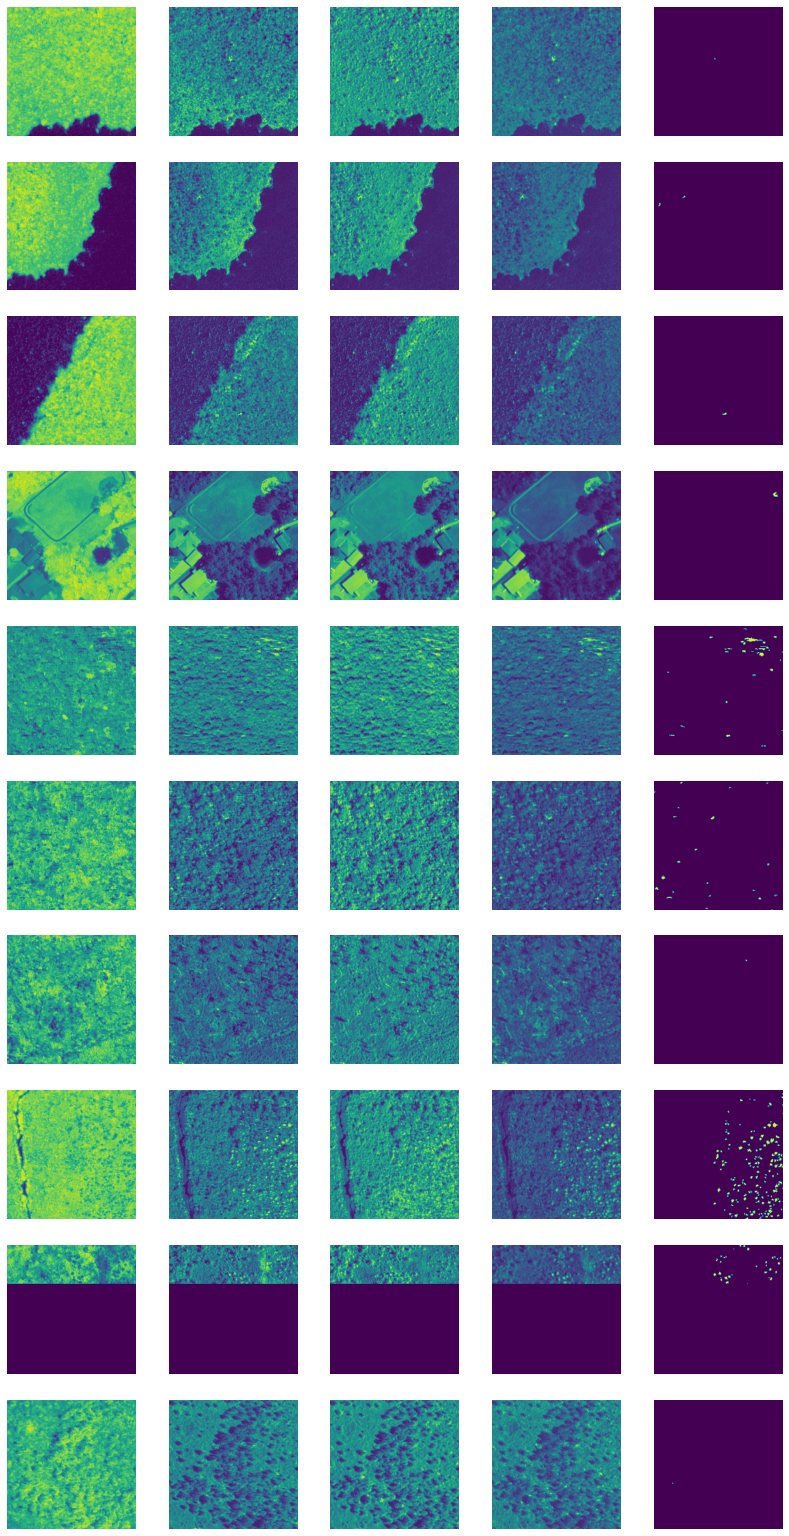

In [6]:
# Display the some of the test images
numberOfImagesToDisplay = 10
test_patches = train_generator_filter #or val_generator

train_images, real_label = test_patches[0][:numberOfImagesToDisplay], test_patches[1][...,[0]][:numberOfImagesToDisplay]
display_images(np.concatenate((train_images[...,[0,1,2,3]],real_label), axis = -1))
print(train_images.max())

In [7]:
from deepstack.base import KerasMember
from deepstack.ensemble import StackEnsemble, DirichletEnsemble
# from segmentation_models import Unet
# from segmentation_models.utils import set_regularization
# from tensorflow.keras import regularizers
# from tensorflow.keras.layers import Input, Conv2D
# from tensorflow.keras.models import Model

OPTIMIZER = adam
LOSS = focal_tversky 
thres = 0.5

# Define model path
model1_path = os.path.join(config.model_path, config.model1_name+config.model_type)
model2_path = os.path.join(config.model_path, config.model2_name+config.model_type)
model3_path = os.path.join(config.model_path, config.model3_name+config.model_type)

# Load Models
model1 = load_model(model1_path, custom_objects={'ftversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=thres), 'IOU-Score': IOUScore(class_indexes=0, threshold=thres), 'Precision': Precision(class_indexes=0, threshold=thres), 'Recall': Recall(class_indexes=0, threshold=thres)}, compile=False) 
model2 = load_model(model2_path, custom_objects={'ftversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=thres), 'IOU-Score': IOUScore(class_indexes=0, threshold=thres), 'Precision': Precision(class_indexes=0, threshold=thres), 'Recall': Recall(class_indexes=0, threshold=thres)}, compile=False)
model3 = load_model(model3_path, custom_objects={'ftversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=thres), 'IOU-Score': IOUScore(class_indexes=0, threshold=thres), 'Precision': Precision(class_indexes=0, threshold=thres), 'Recall': Recall(class_indexes=0, threshold=thres)}, compile=False)

# Assign Ensemble Member
member1 = KerasMember(name="Model1", keras_model=model1, train_batches=(train_x, train_y), val_batches=(val_x, val_y))
member2 = KerasMember(name="Model2", keras_model=model2, train_batches=(train_x, train_y), val_batches=(val_x, val_y))
member3 = KerasMember(name="Model3", keras_model=model3, train_batches=(train_x, train_y), val_batches=(val_x, val_y))
# member1 = KerasMember(name="Model1", keras_model=model1, train_batches=train_generator, val_batches=val_generator)
# member2 = KerasMember(name="Model2", keras_model=model2, train_batches=train_generator, val_batches=val_generator)
# member3 = KerasMember(name="Model3", keras_model=model3, train_batches=train_generator, val_batches=val_generator)

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score
wAvgEnsemble = DirichletEnsemble(N=1000, metric=f1_score)
wAvgEnsemble.add_members([member1, member2, member3]) # Assumption: the data iterators of base-learners iterate over the same data and have same shape and classes.
wAvgEnsemble.fit(reshape=True, threshold=0.5) # Fits meta-learner based on training batches from 
wAvgEnsemble.describe(reshape=True, threshold=0.5)

100%|██████████| 1000/1000 [24:36<00:00,  1.48s/it] 


Model1 - Weight: 0.4014 - f1_score: 0.7424
Model2 - Weight: 0.0993 - f1_score: 0.7503
Model3 - Weight: 0.4992 - f1_score: 0.7660
DirichletEnsemble f1_score: 0.7705


In [12]:
from sklearn.ensemble import RandomForestRegressor

stack = StackEnsemble()
stack.model = RandomForestRegressor(verbose=1, n_estimators=150, 
                                   max_depth=15, n_jobs=20, min_samples_split=20)
stack.add_members([member1, member2, member3])
stack.fit()
stack.describe(reshape=True, threshold=0.5, metric=f1_score)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


KeyboardInterrupt: 

In [11]:
import keras
from keras.utils.data_utils import get_file
data_path = get_file('cifar10_samples.npz',
            'https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10_samples.npz')
data = np.load(data_path)
x_train, y_train, x_val, y_val = [item[1] for item in data.items()]


#Source Code: https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10SimpleCNN.py
model_path1 = get_file('cifar10SimpleCNN.h5',
            'https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10SimpleCNN.h5')
model1 = keras.models.load_model(model_path1)

#Source Code: https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10SimpleCNN2.py
model_path2 = get_file('cifar10SimpleCNN2.h5',
            'https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10SimpleCNN2.h5')
model2 = keras.models.load_model(model_path2)

#Source Code: https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10keras.py
model_path3 = get_file('cifar10keras.h5',
            'https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10keras.h5')
model3 = keras.models.load_model(model_path3)

#Source Code: https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10vgg.py
model_path4 = get_file('cifar10vgg.h5',
            'https://github.com/jcborges/DeepStack/releases/download/Cifar10/cifar10vgg.h5')
model4 = keras.models.load_model(model_path4)

member1 = KerasMember(name="model1", keras_model=model1, train_batches=(x_train, y_train), val_batches=(x_val, y_val))
member2 = KerasMember(name="model2", keras_model=model2, train_batches=(x_train, y_train), val_batches=(x_val, y_val))
member3 = KerasMember(name="model3", keras_model=model3, train_batches=(x_train, y_train), val_batches=(x_val, y_val))
member4 = KerasMember(name="model4", keras_model=model4, train_batches=(x_train, y_train), val_batches=(x_val, y_val))


#Licence: MIT
from deepstack.ensemble import StackEnsemble
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

stack = StackEnsemble()
stack.model = RandomForestRegressor(verbose=0, n_estimators=200, 
                                  max_depth=15, n_jobs=20, min_samples_split=20)
stack.add_members([member1, member2, member3, member4])
stack.fit()
stack.describe(metric = accuracy_score)

RandomForestRegressor(max_depth=15, min_samples_split=20, n_estimators=200,
                      n_jobs=20)

  0%|          | 0/4 [00:00<?, ?it/s]

Calling predict


AttributeError: 'KerasMember' object has no attribute 'val_classes_flatten'

In [ ]:

#Only for the name of the model in the very end
OPTIMIZER_NAME = 'Adam'
LOSS_NAME = 'weightmap_ftversky5575' #alpha, beta, gamma
BACKBONE_NAME = str(config.BACKBONE)+'pt' if config.PRETRAIN else str(config.BACKBONE)

# Declare the path to the final model
# If you want to retrain an exising model then change the cell where model is declared. 
# This path is for storing a model after training.

timestr = time.strftime("%Y%m%d-%H%M")
chf = config.input_image_channel + config.input_label_channel
chs = reduce(lambda a,b: a+str(b), chf, '')


if not os.path.exists(config.model_path):
    os.makedirs(config.model_path)
model_path = os.path.join(config.model_path,'trees_{}_{}_{}_{}_{}_{}.h5'.format(BACKBONE_NAME,timestr,OPTIMIZER_NAME,LOSS_NAME,chs,config.input_shape[0]))

# The weights without the model architecture can also be saved. Just saving the weights is more efficent.

# weight_path="./saved_weights/UNet/{}/".format(timestr)
# if not os.path.exists(weight_path):
#     os.makedirs(weight_path)
# weight_path=weight_path + "{}_weights.best.hdf5".format('UNet_model')
# print(weight_path)

In [ ]:
# # Define the model and compile it
# model = UNet([config.BATCH_SIZE, *config.input_shape],config.input_label_channel)

from segmentation_models import Unet
from segmentation_models.utils import set_regularization
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Model

# Define the model and compile it
base_model = Unet(config.BACKBONE, classes=1, activation='sigmoid', encoder_weights=config.PRETRAIN, encoder_freeze=False, decoder_use_batchnorm=True)
inp = Input(shape=config.input_shape)
l1 = Conv2D(3, (1, 1))(inp)
out = base_model(l1)
model = Model(inp, out, name=base_model.name)
model = set_regularization(model, kernel_regularizer=regularizers.l2(0.001))
model.summary()

model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=0.5), IOUScore(class_indexes=0, threshold=0.5), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])
print(f'Model is pretrained on {str(config.PRETRAIN)} with {str(config.BACKBONE)} encoder backbone')

In [ ]:
# Define callbacks for the early stopping of training, LearningRateScheduler and model checkpointing
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard


checkpoint = ModelCheckpoint(model_path, monitor='val_loss', verbose=1, 
                             save_best_only=True, mode='min', save_weights_only = False)

#reduceonplatea; It can be useful when using adam as optimizer
#Reduce learning rate when a metric has stopped improving (after some patience,reduce by a factor of 0.33, new_lr = lr * factor).
#cooldown: number of epochs to wait before resuming normal operation after lr has been reduced.
reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.4,
                                   patience=6, verbose=1, mode='min',
                                   min_delta=0.0001, cooldown=4, min_lr=5e-6)

early = EarlyStopping(monitor="val_loss", mode="min", verbose=2, patience=40)

log_dir = os.path.join('./logs','UNet_{}_{}_{}_{}_{}_{}'.format(BACKBONE_NAME,timestr,OPTIMIZER_NAME,LOSS_NAME,chs, config.input_shape[0]))
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=True, write_grads=False, write_images=False, embeddings_freq=0, embeddings_layer_names=None, embeddings_metadata=None, embeddings_data=None, update_freq='epoch')

callbacks_list = [checkpoint, early, reduceLROnPlat, tensorboard] #reduceLROnPlat is not required with adaDelta

In [ ]:
loss_history = [model.fit(train_generator, 
                         steps_per_epoch=config.MAX_TRAIN_STEPS, 
                         epochs=config.NB_EPOCHS, 
                         validation_data=val_generator,
                         validation_steps=config.VALID_IMG_COUNT,
                         callbacks=callbacks_list,
                         workers=2,
                         max_queue_size=5,
                         use_multiprocessing=True # the generator is not very thread safe
                        )]

In [ ]:
# Load model after training
# If you load a model with different python version, than you may run into a problem: https://github.com/keras-team/keras/issues/9595#issue-303471777

model_path = './saved_models/UNet/trees_inceptionv3pt_20230506-1222_Adam_weightmap_ftversky5575_012345_256.h5'
model = load_model(model_path, custom_objects={'tversky': LOSS, 'DiceLoss': DiceLoss(class_indexes=0), 'JaccardLoss': JaccardLoss(class_indexes=0), 'F1-Score': FScore(class_indexes=0, threshold=0.5), 'IOU-Score': IOUScore(class_indexes=0, threshold=0.5), 'Precision': Precision(class_indexes=0, threshold=0.5), 'Recall': Recall(class_indexes=0, threshold=0.5)}, compile=False)
# In case you want to use multiple GPU you can uncomment the following lines.
# from tensorflow.python.keras.utils import multi_gpu_model
# model = multi_gpu_model(model, gpus=8, cpu_merge=False)

model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[DiceLoss(class_indexes=0), JaccardLoss(class_indexes=0), FScore(class_indexes=0, threshold=0.5), IOUScore(class_indexes=0, threshold=0.5), Precision(class_indexes=0, threshold=0.5), Recall(class_indexes=0, threshold=0.5)])

In [ ]:
# Print one batch on the training/test data!
for i in range(5):
    test_images, real_label = next(val_generator)
    #5 images per row: pan, ndvi, label, weight, prediction
    prediction = model.predict(test_images, steps=1)
#     prediction[prediction>0.5]=1
#     prediction[prediction<=0.5]=0
    display_images(np.concatenate((test_images[...,[0,1,3]],real_label, prediction), axis = -1))

In [ ]:
# Compare model
for i in range(1):
    test_images, real_label = next(val_generator)
    #5 images per row: pan, ndvi, label, weight, prediction

# #     unet_eff_prediction = unet_eff.predict(test_images, steps=1)
#     unet_res_prediction = unet_res.predict(test_images, steps=1)
# #     unet_inc_prediction = unet_inc.predict(test_images, steps=1)
# #     preds = np.array([unet_res_prediction,unet_inc_prediction])
# #     weights = [0.5, 0.5]
# #     weighted_preds = np.tensordot(preds, weights, axes=((0),(0)))
# #     weighted_preds[weighted_preds>0.5]=1
# #     weighted_preds[weighted_preds<=0.5]=0    
#     display_images(np.concatenate((test_images[...,[0,3]], real_label[...,[0]], unet_res_prediction), axis = -1))

In [ ]:
for i in range(2):
    test_images, real_label = next(val_generator)
    #5 images per row: pan, ndvi, label, weight, prediction
#     unet_ori_tl64_prediction = unet_ori_tl64.predict(test_images, steps=1)
#     unet_ori_tl64_prediction[unet_ori_tl64_prediction>0.5]=1
#     unet_ori_tl64_prediction[unet_ori_tl64_prediction<=0.5]=0

    unet_res_tl64_prediction = unet_res_tl64.predict(test_images, steps=1)
    unet_res_tl55_prediction = unet_res_tl55.predict(test_images, steps=1)
    unet_res_tl46_prediction = unet_res_tl46.predict(test_images, steps=1)
    unet_res_tl64_prediction[unet_res_tl64_prediction>0.5]=1
    unet_res_tl64_prediction[unet_res_tl64_prediction<=0.5]=0    
    unet_res_tl55_prediction[unet_res_tl55_prediction>0.5]=1
    unet_res_tl55_prediction[unet_res_tl55_prediction<=0.5]=0    
    unet_res_tl46_prediction[unet_res_tl46_prediction>0.5]=1
    unet_res_tl46_prediction[unet_res_tl46_prediction<=0.5]=0    
    display_images(np.concatenate((test_images[...,[0]], real_label[...,[0]], unet_res_tl64_prediction, unet_res_tl55_prediction, unet_res_tl46_prediction), axis = -1))